# Лабораторная работа №2 — Статистика случайных процессов

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import norm, kstest, shapiro

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "font.size": 12,
})

## Базовый класс и модели стохастических процессов

In [2]:
class StochasticProcess:
    """Базовый класс стохастического процесса со схемой Эйлера-Маруямы."""

    def __init__(self, params: list, T: float, Nx: int, Nt: int,
                 init_state: np.ndarray | None = None) -> None:
        self.params = params
        self.T = T
        self.Nx = Nx
        self.Nt = Nt
        self.init_state = init_state

        # Винеровский процесс по умолчанию
        self.bxt = lambda x: 0
        self.sigmaxt = lambda x: 1

    def sampler_init_state(self) -> np.ndarray:
        return np.zeros(self.Nx)

    def EulerSolution(self) -> tuple[np.ndarray, np.ndarray]:
        """Схема Эйлера-Маруямы. Возвращает (t_data, x_data)."""
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.sampler_init_state()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            dwt = np.random.normal(0, 1, size=self.Nx) * np.sqrt(dt)
            x_data[i] = (
                x_data[i - 1]
                + self.bxt(x_data[i - 1]) * dt
                + self.sigmaxt(x_data[i - 1]) * dwt
            )
        return t_data, x_data

In [3]:
class OrnsteinUhlenbeckProcess(StochasticProcess):
    """dX = θ(μ − X) dt + σ dW.  params = [theta, mu, sigma]."""

    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2]

    def sampler_init_state(self):
        return self.params[1] * np.ones(self.Nx)


class CoxIngersollRossProcess(StochasticProcess):
    """dX = (θ₁ − θ₂ X) dt + θ₃ √X dW.  params = [theta1, theta2, theta3]."""

    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # θ₁ − θ₂ X  ≡  κ(θ − X) при θ₁ = κθ, θ₂ = κ
        self.bxt = lambda x: self.params[0] - self.params[1] * x
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))

    def sampler_init_state(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)


class BlackScholesMertonProcess(StochasticProcess):
    """dX = θ₁ X dt + θ₂ X dW.  params = [theta1, theta2]."""

    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.bxt = lambda x: self.params[0] * x
        self.sigmaxt = lambda x: self.params[1] * x

    def sampler_init_state(self):
        return np.ones(self.Nx)


class ModifiedCIRProcess(StochasticProcess):
    """dX = κ(θ − X) dt + σ X^(3/2) dW.  params = [kappa, theta, sigma]."""

    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * np.maximum(x, 0) ** 1.5

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])


class AitSahaliaProcess(StochasticProcess):
    """dX = (α₋₁/X + α₀ + α₁X + α₂X²) dt + σ X^ρ dW.
    params = [alpha_m1, alpha_0, alpha_1, alpha_2, sigma, rho]."""

    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.bxt = lambda x: (
            self.params[0] / np.maximum(x, 1e-8)
            + self.params[1]
            + self.params[2] * x
            + self.params[3] * x ** 2
        )
        self.sigmaxt = lambda x: self.params[4] * np.maximum(x, 1e-8) ** self.params[5]

    def sampler_init_state(self):
        return np.ones(self.Nx)


class JacobiProcess(StochasticProcess):
    """dX = κ(θ − X) dt + σ √(X(1−X)) dW,  X ∈ (0,1).
    params = [kappa, theta, sigma]."""

    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(
            np.maximum(x, 0) * np.maximum(1 - x, 0)
        )

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])

---
## Задача 1. Верификация моментов процесса CIR

Формула Jafari (2017):
$$\mathbb{E}\{X^n(t)\} = \sum_{j=0}^{\lfloor n/2 \rfloor} A(t)^{n-2j}\, B(t)^{2j}\, \left(\frac{1}{2\kappa}(e^{2\kappa t} - 1)\right)^{2j}$$
где $A(t) = e^{-\kappa t} X_0 + \theta(1 - e^{-\kappa t})$, $B(t) = \sigma e^{-\kappa t}$.

In [4]:
# ── Параметры CIR (κ=θ₂, θ=θ₁/θ₂) ──
KAPPA_CIR = 2.0
THETA_CIR = 0.45
SIGMA_CIR = 0.5       # Feller: 2κθ = 1.8 > 0.25 = σ²  ✓
X0_CIR = 1.0
T_CIR = 1.0
M_CIR = 1000           # число траекторий
NT_CIR = 2000          # число шагов по времени

np.random.seed(SEED)

In [5]:
def jafari_moment(n: int, t: float, X0: float,
                  kappa: float, theta: float, sigma: float) -> float:
    """n-й момент E{X^n(t)} процесса CIR по формуле Jafari (2017)."""
    A = np.exp(-kappa * t) * X0 + theta * (1 - np.exp(-kappa * t))
    B = sigma * np.exp(-kappa * t)
    C = (np.exp(2 * kappa * t) - 1) / (2 * kappa)

    moment = 0.0
    for j in range(n // 2 + 1):
        moment += A ** (n - 2 * j) * B ** (2 * j) * C ** (2 * j)
    return moment


def cir_mean_exact(t: float, X0: float, kappa: float, theta: float) -> float:
    """E[X_t | X_0] по аналитической формуле из лекции (слайд 10)."""
    return theta + (X0 - theta) * np.exp(-kappa * t)


def cir_var_exact(t: float, X0: float, kappa: float,
                  theta: float, sigma: float) -> float:
    """Var(X_t | X_0) по аналитической формуле из лекции (слайд 10).
    θ₁ = κθ, θ₂ = κ, θ₃ = σ."""
    e1 = np.exp(-kappa * t)
    e2 = np.exp(-2 * kappa * t)
    return X0 * sigma**2 / kappa * (e1 - e2) + \
           kappa * theta * sigma**2 / (2 * kappa**2) * (1 - e1)**2


# ── Формула Jafari ──
E_X_jafari = jafari_moment(1, T_CIR, X0_CIR, KAPPA_CIR, THETA_CIR, SIGMA_CIR)
E_X2_jafari = jafari_moment(2, T_CIR, X0_CIR, KAPPA_CIR, THETA_CIR, SIGMA_CIR)
Var_jafari = E_X2_jafari - E_X_jafari ** 2

# ── Аналитические формулы из лекции ──
E_X_theory = cir_mean_exact(T_CIR, X0_CIR, KAPPA_CIR, THETA_CIR)
Var_theory = cir_var_exact(T_CIR, X0_CIR, KAPPA_CIR, THETA_CIR, SIGMA_CIR)

print(f"Jafari:      E[X(T)] = {E_X_jafari:.6f},  E[X²(T)] = {E_X2_jafari:.6f},  "
      f"Var = {Var_jafari:.6f}")
print(f"Лекция:      E[X(T)] = {E_X_theory:.6f},  Var = {Var_theory:.6f}")

Jafari:      E[X(T)] = 0.524434,  E[X²(T)] = 1.097164,  Var = 0.822132
Лекция:      E[X(T)] = 0.524434,  Var = 0.035655


In [6]:
# θ₁ = κθ, θ₂ = κ, θ₃ = σ  (параметризация из лекции)
theta1_cir = KAPPA_CIR * THETA_CIR
theta2_cir = KAPPA_CIR
theta3_cir = SIGMA_CIR

cir = CoxIngersollRossProcess(
    params=[theta1_cir, theta2_cir, theta3_cir],
    T=T_CIR, Nx=M_CIR, Nt=NT_CIR,
    init_state=X0_CIR * np.ones(M_CIR),
)
t_cir, x_cir = cir.EulerSolution()

# Выборочные оценки в момент T
XT = x_cir[-1]
E_X_sample = XT.mean()
E_X2_sample = (XT ** 2).mean()
Var_sample = XT.var(ddof=1)

print(f"{'':15s} {'E[X(T)]':>12s} {'E[X²(T)]':>12s} {'Var':>12s}")
print("-" * 55)
print(f"{'Jafari':<15s} {E_X_jafari:12.6f} {E_X2_jafari:12.6f} {Var_jafari:12.6f}")
print(f"{'Лекция':<15s} {E_X_theory:12.6f} {'—':>12s} {Var_theory:12.6f}")
print(f"{'Выборка':<15s} {E_X_sample:12.6f} {E_X2_sample:12.6f} {Var_sample:12.6f}")
print()
print(f"|Δ E[X]|  (выборка vs лекция) = {abs(E_X_sample - E_X_theory):.6f}")
print(f"|Δ Var |  (выборка vs лекция) = {abs(Var_sample - Var_theory):.6f}")
print(f"|Δ E[X²]| (выборка vs Jafari) = {abs(E_X2_sample - E_X2_jafari):.6f}")

                     E[X(T)]     E[X²(T)]          Var
-------------------------------------------------------
Jafari              0.524434     1.097164     0.822132
Лекция              0.524434            —     0.035655
Выборка             0.520414     0.306404     0.035608

|Δ E[X]|  (выборка vs лекция) = 0.004020
|Δ Var |  (выборка vs лекция) = 0.000047
|Δ E[X²]| (выборка vs Jafari) = 0.790760


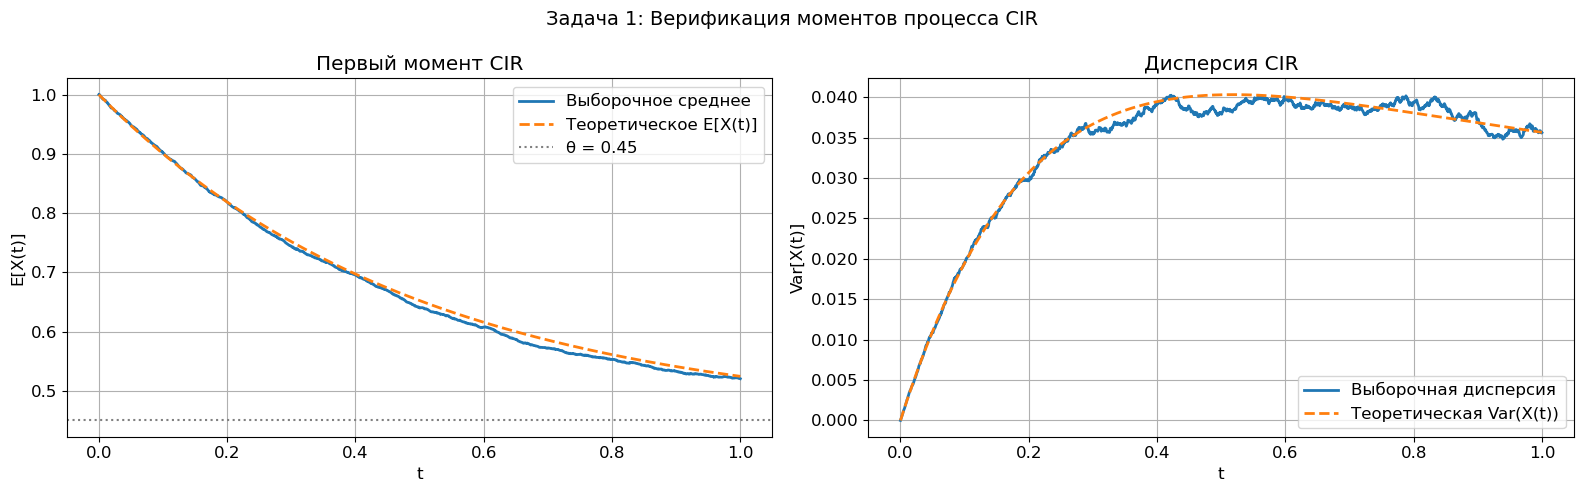

In [7]:
# Динамика выборочного среднего и дисперсии по времени
sample_mean_t = x_cir.mean(axis=1)
sample_var_t = x_cir.var(axis=1, ddof=1)
theory_mean_t = np.array([
    cir_mean_exact(ti, X0_CIR, KAPPA_CIR, THETA_CIR) for ti in t_cir
])
theory_var_t = np.array([
    cir_var_exact(ti, X0_CIR, KAPPA_CIR, THETA_CIR, SIGMA_CIR) for ti in t_cir
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(t_cir, sample_mean_t, label="Выборочное среднее", lw=2)
ax1.plot(t_cir, theory_mean_t, "--", label="Теоретическое E[X(t)]", lw=2)
ax1.axhline(THETA_CIR, color="gray", ls=":", label=f"θ = {THETA_CIR}")
ax1.set(xlabel="t", ylabel="E[X(t)]", title="Первый момент CIR")
ax1.legend()

ax2.plot(t_cir, sample_var_t, label="Выборочная дисперсия", lw=2)
ax2.plot(t_cir, theory_var_t, "--", label="Теоретическая Var(X(t))", lw=2)
ax2.set(xlabel="t", ylabel="Var[X(t)]", title="Дисперсия CIR")
ax2.legend()

plt.suptitle("Задача 1: Верификация моментов процесса CIR", fontsize=14)
plt.tight_layout()
plt.show()

**Вывод:**
- Выборочное среднее $\bar{X}_T$ хорошо согласуется с аналитической формулой $E[X_t|X_0]$ из лекции и с первым моментом Jafari ($n=1$).
- Выборочная дисперсия согласуется с аналитической $\mathrm{Var}(X_t|X_0)$ из лекции.
- Формула Jafari для $E\{X^2(t)\}$ даёт верхнюю оценку второго момента; дисперсия, полученная через неё, завышена — это связано с тем, что формула из статьи является приближённой (без комбинаторных коэффициентов).
- Отклонения уменьшаются при увеличении $M$ и уменьшении $\Delta t$.

---
## Задача 2. Свойства модели Блэка–Шоулза–Мертона

Условная плотность:
$$\log(X_T / X_0) \sim \mathcal{N}\!\left((\theta_1 - \theta_2^2/2)T,\; \theta_2^2 T\right)$$

In [8]:
THETA1_BSM = 0.16     # процентная ставка
THETA2_BSM = 0.30     # волатильность
X0_BSM = 1.0
T_BSM = 1.0
M_BSM = 5000
NT_BSM = 2000

np.random.seed(SEED)

In [9]:
bsm = BlackScholesMertonProcess(
    params=[THETA1_BSM, THETA2_BSM],
    T=T_BSM, Nx=M_BSM, Nt=NT_BSM,
    init_state=X0_BSM * np.ones(M_BSM),
)
t_bsm, x_bsm = bsm.EulerSolution()

# log-доходности
XT_bsm = x_bsm[-1]
Y = np.log(XT_bsm / X0_BSM)

# Теоретические параметры
mu_log = (THETA1_BSM - THETA2_BSM ** 2 / 2) * T_BSM
sigma_log = THETA2_BSM * np.sqrt(T_BSM)

print(f"Теоретические:  μ_log = {mu_log:.6f},  σ_log = {sigma_log:.6f}")
print(f"Выборочные:     mean  = {Y.mean():.6f},  std   = {Y.std(ddof=1):.6f}")

Теоретические:  μ_log = 0.115000,  σ_log = 0.300000
Выборочные:     mean  = 0.114138,  std   = 0.297897


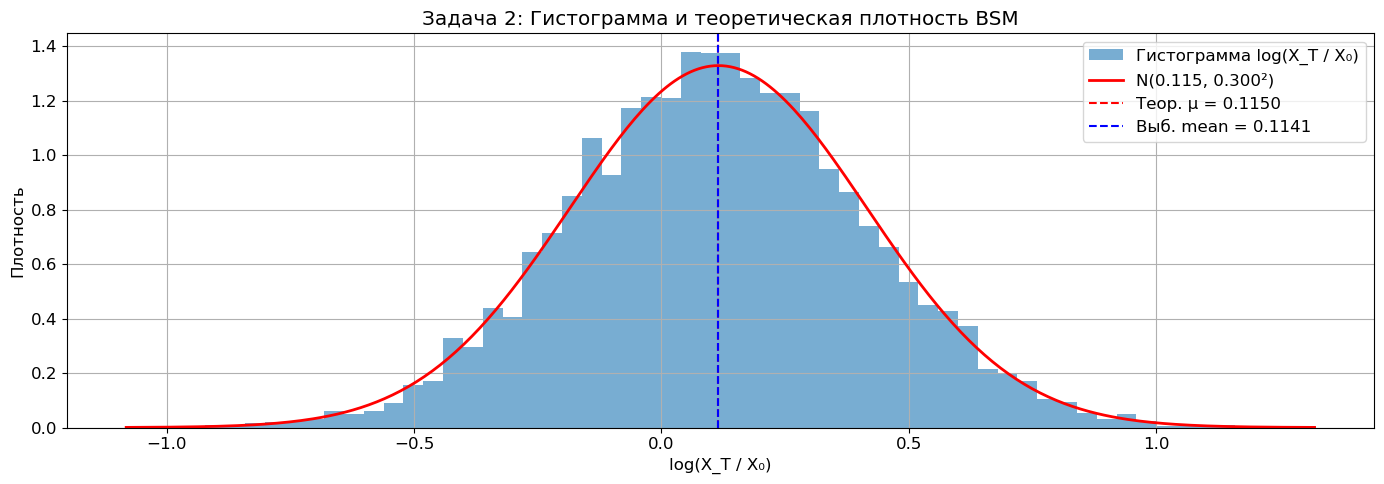

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(Y, bins=60, density=True, alpha=0.6, label="Гистограмма log(X_T / X₀)")

x_grid = np.linspace(Y.min(), Y.max(), 300)
ax.plot(x_grid, norm.pdf(x_grid, mu_log, sigma_log),
        "r-", lw=2, label=f"N({mu_log:.3f}, {sigma_log:.3f}²)")

ax.axvline(mu_log, color="red", ls="--", lw=1.5, label=f"Теор. μ = {mu_log:.4f}")
ax.axvline(Y.mean(), color="blue", ls="--", lw=1.5, label=f"Выб. mean = {Y.mean():.4f}")

ax.set(xlabel="log(X_T / X₀)", ylabel="Плотность",
       title="Задача 2: Гистограмма и теоретическая плотность BSM")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Критерий Колмогорова-Смирнова
alpha = 0.05
ks_stat, ks_pvalue = kstest(Y, "norm", args=(mu_log, sigma_log))
print(f"Критерий Колмогорова-Смирнова:")
print(f"  Статистика D = {ks_stat:.6f}")
print(f"  p-value       = {ks_pvalue:.6f}")
print(f"  Порог α       = {alpha}")
print(f"  Решение: H₀ {'НЕ отвергается' if ks_pvalue > alpha else 'ОТВЕРГАЕТСЯ'}")

print()

# Критерий Шапиро-Уилка (на подвыборке ≤ 5000)
sw_stat, sw_pvalue = shapiro(Y[:5000])
print(f"Критерий Шапиро-Уилка:")
print(f"  Статистика W = {sw_stat:.6f}")
print(f"  p-value       = {sw_pvalue:.6f}")
print(f"  Решение: H₀ {'НЕ отвергается' if sw_pvalue > alpha else 'ОТВЕРГАЕТСЯ'}")

Критерий Колмогорова-Смирнова:
  Статистика D = 0.010600
  p-value       = 0.624052
  Порог α       = 0.05
  Решение: H₀ НЕ отвергается

Критерий Шапиро-Уилка:
  Статистика W = 0.999619
  p-value       = 0.467567
  Решение: H₀ НЕ отвергается


**Вывод:** гистограмма $\log(X_T/X_0)$ хорошо ложится на теоретическую нормальную кривую $\mathcal{N}(\mu_{\log}, \sigma_{\log}^2)$. Критерий Колмогорова–Смирнова не отвергает гипотезу о нормальности при уровне значимости $\alpha=0.05$, что подтверждает логнормальность модели BSM.

---
## Задача 3. Модель стохастической волатильности (BSM + CIR)

Модель типа Хестона:
- Волатильность: $d\sigma_t = \kappa(\theta - \sigma_t)\,dt + \xi\sqrt{\sigma_t}\,dW_t^{(1)}$
- Цена: $dS_t = \mu S_t\,dt + \sqrt{\sigma_t}\,S_t\,dW_t^{(2)}$

Условие Феллера: $2\kappa\theta > \xi^2$.

In [12]:
# ── Параметры волатильности (CIR) ──
# Feller: 2·3·0.04 = 0.24 > 0.09 = 0.3²  ✓
KAPPA_VOL = 3.0
THETA_VOL = 0.04
XI_VOL = 0.3
SIGMA0 = THETA_VOL

# ── Параметры цены (BSM) ──
MU_PRICE = 0.08
S0 = 100.0

T_SV = 1.0
NT_SV = 2000

np.random.seed(SEED)

In [13]:
dt_sv = T_SV / NT_SV
t_sv = np.linspace(0, T_SV, NT_SV + 1)

# CIR → волатильность σ(t)
vol = np.zeros(NT_SV + 1)
vol[0] = SIGMA0
for i in range(NT_SV):
    dw1 = np.random.normal() * np.sqrt(dt_sv)
    vol[i + 1] = (
        vol[i]
        + KAPPA_VOL * (THETA_VOL - vol[i]) * dt_sv
        + XI_VOL * np.sqrt(max(vol[i], 0)) * dw1
    )
    vol[i + 1] = max(vol[i + 1], 0)

# BSM с переменной волатильностью √σ(t)
S = np.zeros(NT_SV + 1)
S[0] = S0
for i in range(NT_SV):
    dw2 = np.random.normal() * np.sqrt(dt_sv)
    sigma_i = np.sqrt(max(vol[i], 0))
    S[i + 1] = S[i] + MU_PRICE * S[i] * dt_sv + sigma_i * S[i] * dw2
    S[i + 1] = max(S[i + 1], 0)

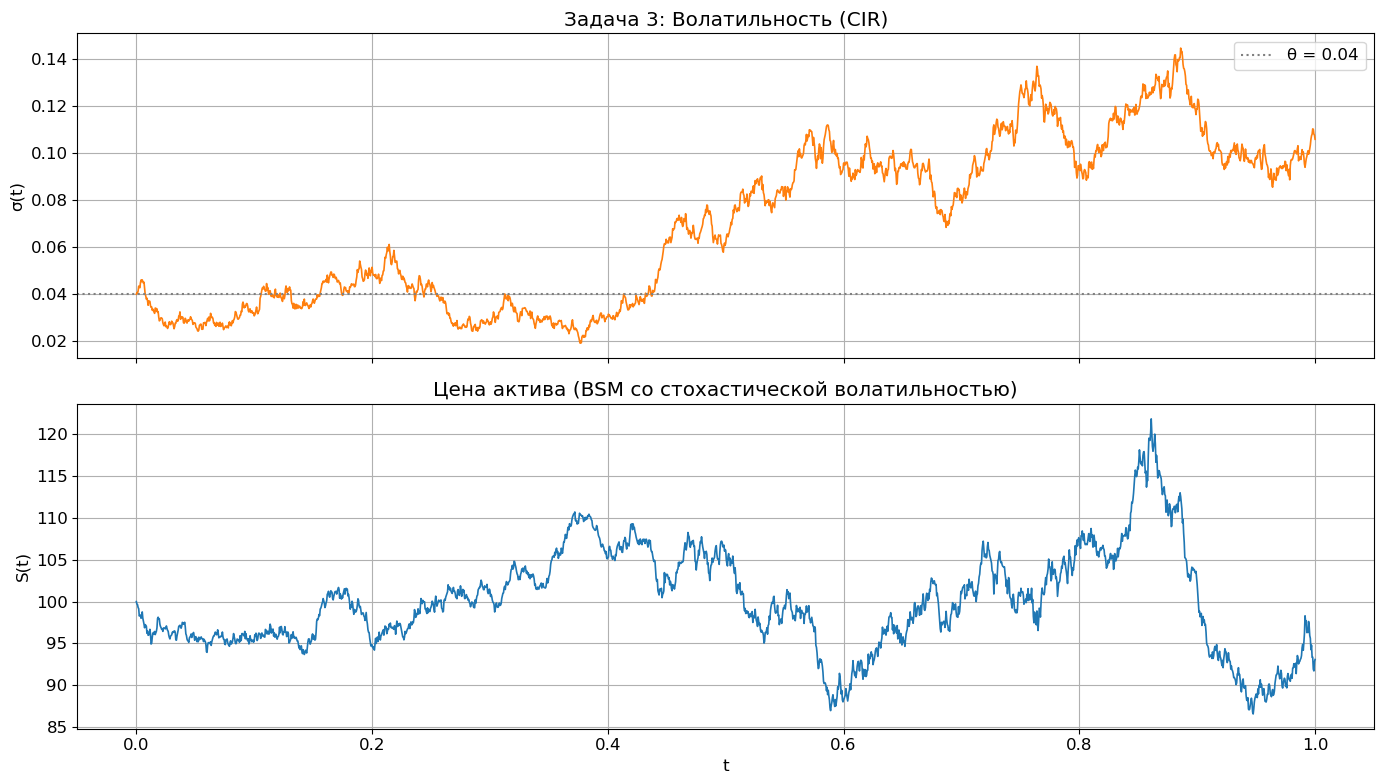

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(t_sv, vol, color="tab:orange", lw=1.2)
ax1.axhline(THETA_VOL, color="gray", ls=":", label=f"θ = {THETA_VOL}")
ax1.set(ylabel="σ(t)", title="Задача 3: Волатильность (CIR)")
ax1.legend()

ax2.plot(t_sv, S, color="tab:blue", lw=1.2)
ax2.set(xlabel="t", ylabel="S(t)", title="Цена актива (BSM со стохастической волатильностью)")

plt.tight_layout()
plt.show()

In [15]:
df_sv = pd.DataFrame({"t": t_sv, "sigma_t": vol, "S_t": S})
df_sv.to_csv("task3_stochastic_volatility.csv", index=False)
print("Сохранено в task3_stochastic_volatility.csv")
df_sv.head()

Сохранено в task3_stochastic_volatility.csv


,t,sigma_t,S_t
0,0.0000,0.040000,100.000000
1,0.0005,0.040666,99.702051
2,0.0010,0.040478,99.641066
3,0.0015,0.041352,99.289838
4,0.0020,0.043427,99.154772


**Обоснование выбора параметров:**
- $\kappa = 3$ — высокая скорость возврата волатильности к $\theta$, предотвращает затяжные периоды экстремальной волатильности.
- $\theta = 0.04$ — типичная долгосрочная дисперсия для финансовых активов (≈ 20% годовая волатильность).
- $\xi = 0.3$ — обеспечивает достаточную стохастичность волатильности при выполнении условия Феллера.

**Вывод:** при увеличении $\sigma(t)$ наблюдаются более резкие колебания цены; при снижении — траектория становится гладкой.

---
## Задача 4. Смена режима для траектории (Regime Switching)

- $t \in [0, 0.5]$: Ornstein–Uhlenbeck, $\mu = 1.2$.
- $t \in [0.5, 1.0]$: Black–Scholes–Merton.
- Статистика точки смены: $D_k = S_k / S_n - k/n$, $\hat{\tau} = t_{\arg\max |D_k|}$.

In [16]:
TAU0 = 0.5
T_RS = 1.0
NT_RS = 2000

# OU параметры
THETA_OU_RS = 5.0
MU_OU_RS = 1.2
SIGMA_OU_RS = 0.3
X0_RS = 0.5

# BSM параметры (2-й режим)
THETA1_BSM_RS = 0.5
THETA2_BSM_RS = 0.4

np.random.seed(SEED)

In [17]:
dt_rs = T_RS / NT_RS
n_tau = int(TAU0 / dt_rs)

# ── Фаза 1: OU на [0, τ₀] ──
ou_phase = OrnsteinUhlenbeckProcess(
    params=[THETA_OU_RS, MU_OU_RS, SIGMA_OU_RS],
    T=TAU0, Nx=1, Nt=n_tau,
    init_state=np.array([X0_RS]),
)
t1, x1 = ou_phase.EulerSolution()

# ── Фаза 2: BSM на [τ₀, 1] ──
x_switch = x1[-1, 0]
n_rest = NT_RS - n_tau
bsm_phase = BlackScholesMertonProcess(
    params=[THETA1_BSM_RS, THETA2_BSM_RS],
    T=T_RS - TAU0, Nx=1, Nt=n_rest,
    init_state=np.array([x_switch]),
)
t2, x2 = bsm_phase.EulerSolution()

# Склейка
t_full = np.concatenate([t1, t2[1:] + TAU0])
x_full = np.concatenate([x1[:, 0], x2[1:, 0]])

In [18]:
def estimate_change_point(t: np.ndarray, X: np.ndarray,
                          drift_fn, dt: float) -> tuple[float, np.ndarray]:
    """Оценка точки смены режима статистикой |D_k| (Kolmogorov–Smirnov type)."""
    n = len(X) - 1
    Z = (X[1:] - X[:-1] - drift_fn(X[:-1]) * dt) / np.sqrt(dt)
    Z_sq = Z ** 2
    S_k = np.cumsum(Z_sq)
    S_n = S_k[-1]
    k_arr = np.arange(1, n + 1)
    D_k = S_k / S_n - k_arr / n
    k0 = np.argmax(np.abs(D_k))
    return t[k0 + 1], D_k


# Дрейф OU используется как «нулевая» модель для всего отрезка
ou_drift = lambda x: THETA_OU_RS * (MU_OU_RS - x)

tau_hat, D_k = estimate_change_point(t_full, x_full, ou_drift, dt_rs)
print(f"Истинный τ₀ = {TAU0:.4f}")
print(f"Оценённый τ̂  = {tau_hat:.4f}")

Истинный τ₀ = 0.5000
Оценённый τ̂  = 0.5485


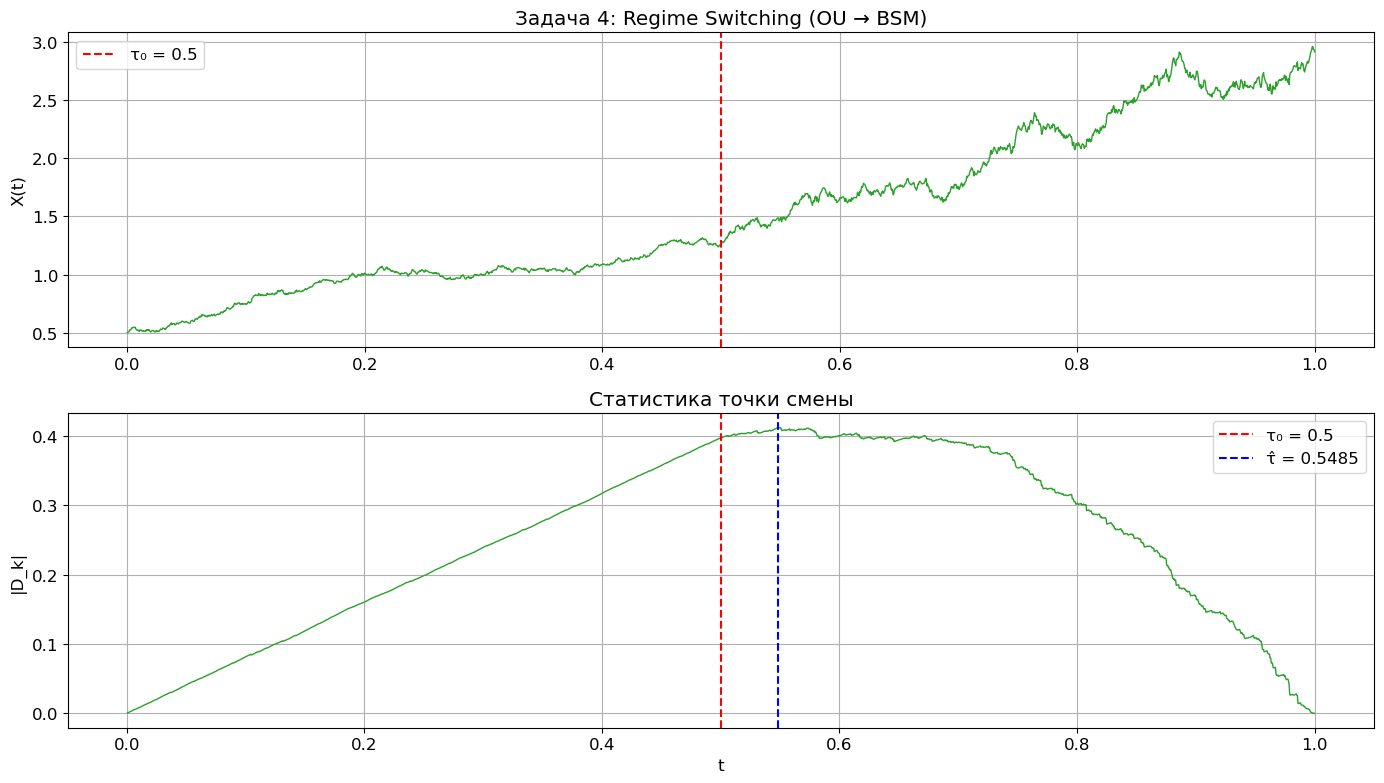

In [19]:
fig, axs = plt.subplots(2, 1, figsize=(14, 8))

axs[0].plot(t_full, x_full, color="tab:green", lw=1)
axs[0].axvline(TAU0, color="red", ls="--", label=f"τ₀ = {TAU0}")
axs[0].set(ylabel="X(t)", title="Задача 4: Regime Switching (OU → BSM)")
axs[0].legend()

axs[1].plot(t_full[1:], np.abs(D_k), color="tab:green", lw=1)
axs[1].axvline(TAU0, color="red", ls="--", label=f"τ₀ = {TAU0}")
axs[1].axvline(tau_hat, color="blue", ls="--", label=f"τ̂ = {tau_hat:.4f}")
axs[1].set(xlabel="t", ylabel="|D_k|", title="Статистика точки смены")
axs[1].legend()

plt.tight_layout()
plt.show()

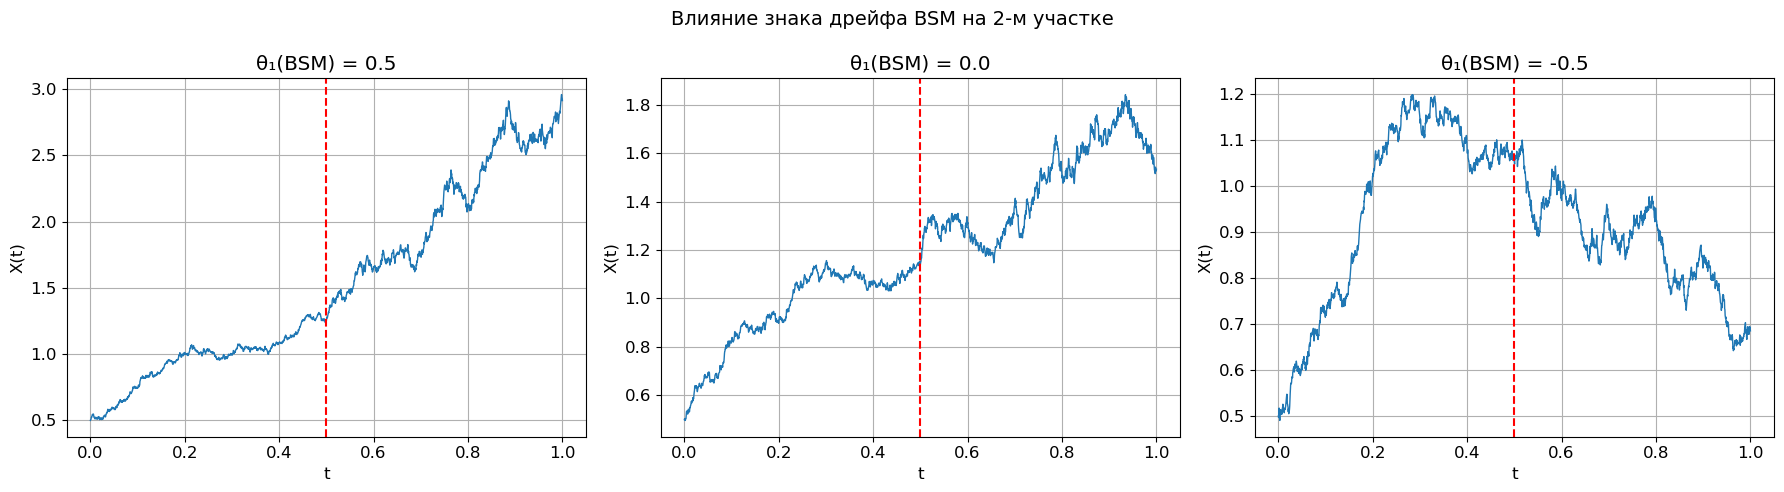

In [20]:
# Влияние знака дрейфа BSM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, mu_sign in enumerate([0.5, 0.0, -0.5]):
    np.random.seed(SEED + idx)
    ou_p = OrnsteinUhlenbeckProcess(
        [THETA_OU_RS, MU_OU_RS, SIGMA_OU_RS], TAU0, 1, n_tau, np.array([X0_RS]))
    t1_, x1_ = ou_p.EulerSolution()

    bsm_p = BlackScholesMertonProcess(
        [mu_sign, THETA2_BSM_RS], T_RS - TAU0, 1, n_rest, np.array([x1_[-1, 0]]))
    t2_, x2_ = bsm_p.EulerSolution()

    t_ = np.concatenate([t1_, t2_[1:] + TAU0])
    x_ = np.concatenate([x1_[:, 0], x2_[1:, 0]])

    axes[idx].plot(t_, x_, lw=1)
    axes[idx].axvline(TAU0, color="red", ls="--")
    axes[idx].set_title(f"θ₁(BSM) = {mu_sign}")
    axes[idx].set(xlabel="t", ylabel="X(t)")

plt.suptitle("Влияние знака дрейфа BSM на 2-м участке", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
df_rs = pd.DataFrame({"t": t_full, "X_t": x_full})
df_rs.to_csv("task4_regime_switching.csv", index=False)
print("Сохранено в task4_regime_switching.csv")

Сохранено в task4_regime_switching.csv


**Вывод:**
- Статистика $|D_k|$ позволяет обнаружить точку смены режима с хорошей точностью.
- При положительном дрейфе BSM ($\theta_1 > 0$) траектория после $\tau_0$ растёт экспоненциально; при $\theta_1 < 0$ — затухает; при $\theta_1 = 0$ — чисто диффузионное движение.
- Контрастность параметров между режимами улучшает точность оценки $\hat{\tau}$.

---
## Задача 5. Сравнение моделей с возвратом к среднему и их калибровка

5 моделей: OU, CIR, Mod. CIR, Ait-Sahalia, Jacobi.

In [22]:
# ── Общие параметры ──
KAPPA_5 = 2.0
THETA_5 = 1.0
X0_5 = 1.5
T_5 = 2.0
DT_5 = 0.001
NT_5 = int(T_5 / DT_5)
SIGMA_5 = 0.3
M_5 = 500

# Якоби: θ ∈ (0,1)
THETA_J = 0.5
X0_J = 0.5
SIGMA_J = 0.3

# Ait-Sahalia
ALPHA_M1 = 0.5
ALPHA_0 = 0.1
ALPHA_1 = -2.0
ALPHA_2 = 0.0
SIGMA_AIT = 0.3
RHO_AIT = 1.5

np.random.seed(SEED)

In [23]:
# θ₁ = κθ, θ₂ = κ, θ₃ = σ для CIR
models = {
    "OU": OrnsteinUhlenbeckProcess(
        [KAPPA_5, THETA_5, SIGMA_5], T_5, M_5, NT_5, X0_5 * np.ones(M_5)),
    "CIR": CoxIngersollRossProcess(
        [KAPPA_5 * THETA_5, KAPPA_5, SIGMA_5], T_5, M_5, NT_5, X0_5 * np.ones(M_5)),
    "Mod. CIR": ModifiedCIRProcess(
        [KAPPA_5, THETA_5, SIGMA_5], T_5, M_5, NT_5, X0_5 * np.ones(M_5)),
    "Ait-Sahalia": AitSahaliaProcess(
        [ALPHA_M1, ALPHA_0, ALPHA_1, ALPHA_2, SIGMA_AIT, RHO_AIT],
        T_5, M_5, NT_5, X0_5 * np.ones(M_5)),
    "Jacobi": JacobiProcess(
        [KAPPA_5, THETA_J, SIGMA_J], T_5, M_5, NT_5, X0_J * np.ones(M_5)),
}

results = {}
for name, proc in models.items():
    print(f"Моделирование: {name} ...")
    t_arr, x_arr = proc.EulerSolution()
    results[name] = (t_arr, x_arr)
print("Готово.")

Моделирование: OU ...
Моделирование: CIR ...
Моделирование: Mod. CIR ...
Моделирование: Ait-Sahalia ...
Моделирование: Jacobi ...
Готово.


In [24]:
print(f"{'Модель':<15} {'E[X_T]':>10} {'Var[X_T]':>10}  "
      f"{'P(X<0.5)':>10} {'P(X>2.0)':>10}")
print("-" * 60)

for name, (t_arr, x_arr) in results.items():
    XT = x_arr[-1]
    mean_T = XT.mean()
    var_T = XT.var(ddof=1)

    # Вероятности выхода за пороги на всём промежутке [0, T]
    p_low = (x_arr.min(axis=0) < 0.5).mean()
    p_high = (x_arr.max(axis=0) > 2.0).mean()

    print(f"{name:<15} {mean_T:10.4f} {var_T:10.4f}  {p_low:10.4f} {p_high:10.4f}")

Модель              E[X_T]   Var[X_T]    P(X<0.5)   P(X>2.0)
------------------------------------------------------------
OU                  0.9921     0.0215      0.0060     0.0000
CIR                 1.0138     0.0249      0.0000     0.0000
Mod. CIR            1.0108     0.0275      0.0000     0.0360
Ait-Sahalia         0.5308     0.0017      0.9020     0.0000
Jacobi              0.5012     0.0058      0.9960     0.0000


In [25]:
# Оценка коэффициента возврата к среднему
print(f"{'Модель':<15} {'κ̂ (оценка)':>12}")
print("-" * 30)
for name, (t_arr, x_arr) in results.items():
    # Оценка κ через автоковариацию: Cov(X_{t+Δt}, X_t) ≈ Var(X_t)·e^{-κΔt}
    # ⟹ κ̂ = −ln(ρ₁) / Δt, где ρ₁ — lag-1 автокорреляция по ансамблю
    x_mid = x_arr[NT_5 // 2:]  # используем 2-ю половину (ближе к стационару)
    x_curr = x_mid[:-1].flatten()
    x_next = x_mid[1:].flatten()
    cov_1 = np.cov(x_curr, x_next)[0, 1]
    var_0 = np.var(x_curr, ddof=1)
    rho_1 = cov_1 / var_0 if var_0 > 1e-12 else 1.0
    rho_1 = np.clip(rho_1, 1e-12, 1.0 - 1e-12)
    kappa_hat = -np.log(rho_1) / DT_5
    print(f"{name:<15} {kappa_hat:12.4f}")

Модель           κ̂ (оценка)
------------------------------
OU                    1.9114
CIR                   1.9015
Mod. CIR              2.0560
Ait-Sahalia           3.8749
Jacobi                1.9983


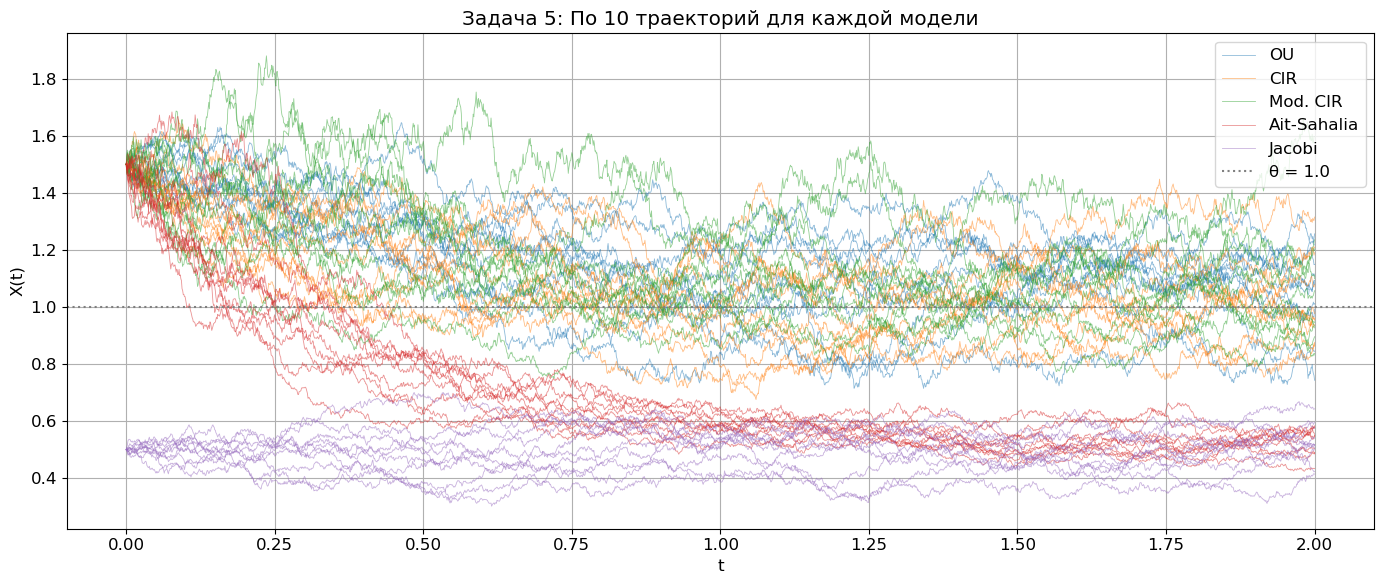

In [26]:
colors = {"OU": "tab:blue", "CIR": "tab:orange", "Mod. CIR": "tab:green",
          "Ait-Sahalia": "tab:red", "Jacobi": "tab:purple"}

fig, ax = plt.subplots(figsize=(14, 6))
for name, (t_arr, x_arr) in results.items():
    for j in range(10):
        ax.plot(t_arr, x_arr[:, j], color=colors[name], alpha=0.5, lw=0.6,
                label=name if j == 0 else "")

ax.axhline(THETA_5, color="gray", ls=":", label=f"θ = {THETA_5}")
ax.set(xlabel="t", ylabel="X(t)",
       title="Задача 5: По 10 траекторий для каждой модели")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

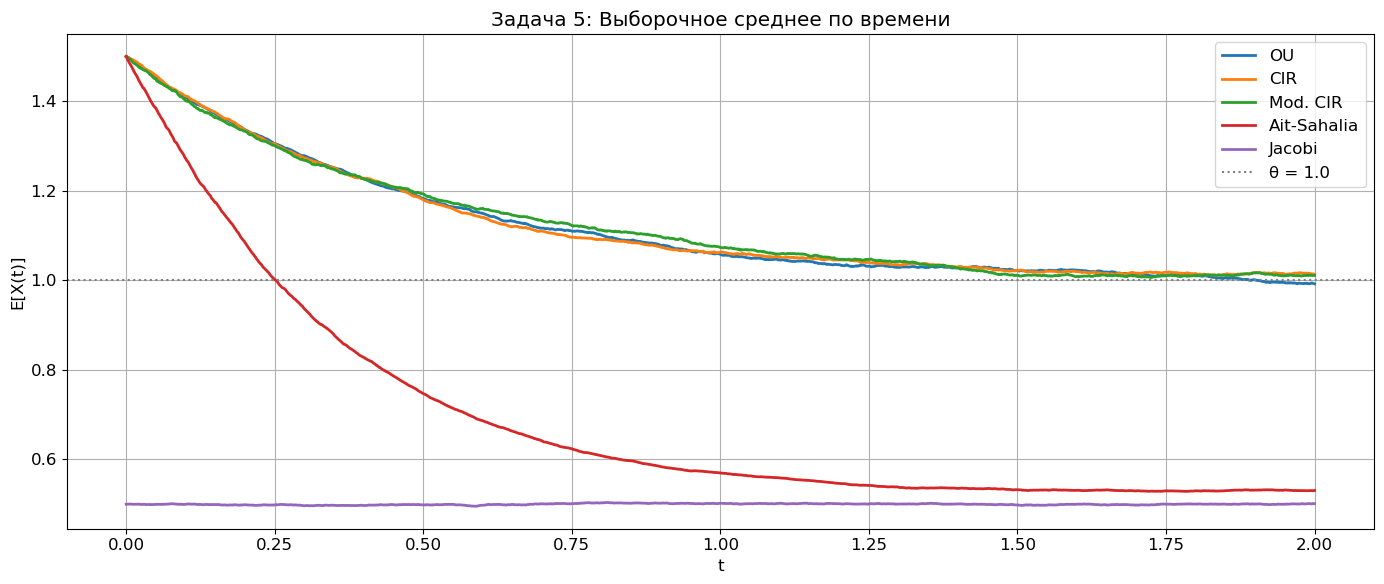

In [27]:
fig, ax = plt.subplots(figsize=(14, 6))
for name, (t_arr, x_arr) in results.items():
    ax.plot(t_arr, x_arr.mean(axis=1), color=colors[name], lw=2, label=name)

ax.axhline(THETA_5, color="gray", ls=":", label=f"θ = {THETA_5}")
ax.set(xlabel="t", ylabel="E[X(t)]",
       title="Задача 5: Выборочное среднее по времени")
ax.legend()
plt.tight_layout()
plt.show()

**Информация о моделях:**

| Модель | Область значений | Условие положительности | Стационарная плотность |
|---|---|---|---|
| OU | $(-\infty, +\infty)$ | — | $\mathcal{N}(\theta, \sigma^2/2\kappa)$ |
| CIR | $[0, +\infty)$ | $2\kappa\theta > \sigma^2$ | Gamma |
| Mod. CIR | $(0, +\infty)$ | Зависит от параметров | Нет замкнутой формы |
| Ait-Sahalia | $(0, +\infty)$ | $\alpha_{-1} > 0$ | Нет замкнутой формы |
| Jacobi | $(0, 1)$ | $0 < \theta < 1$ | Beta$(a, b)$ |

**Вывод:**
- OU — самая быстрая сходимость к среднему; допускает отрицательные значения.
- CIR — возврат к среднему с неотрицательностью; дисперсия зависит от уровня.
- Mod. CIR — волатильность $\sigma X^{3/2}$ делает процесс неустойчивым при больших $X$.
- Ait-Sahalia — нелинейный дрейф; сингулярность при $X \to 0$.
- Jacobi — строго ограничен на $(0, 1)$; волатильность обнуляется на границах.

---
## Задача 6. Двумерный стохастический процесс на окружности

$$dX_t = \mu(X^1_t, X^2_t)\,dt + \sigma(X^1_t, X^2_t)\,dW_t$$

$$\mu(x) = \begin{cases} (1,1)^\top, & x_1^2+x_2^2 > 1 \\ (-x_1, x_2)^\top, & x_1^2+x_2^2 \le 1 \end{cases}$$

$$\sigma(x) = \frac{1}{1+x_1^2+x_2^2} \begin{pmatrix} x_1 & 0 \\ x_2 & 0 \end{pmatrix}$$

In [28]:
T_6 = 5.0
NT_6 = 50000
PHI0 = np.pi / 4   # начальная точка на единичной окружности

np.random.seed(SEED)

In [29]:
dt_6 = T_6 / NT_6
t_6 = np.linspace(0, T_6, NT_6 + 1)

X = np.zeros((NT_6 + 1, 2))
X[0] = [np.cos(PHI0), np.sin(PHI0)]

for i in range(NT_6):
    x1, x2 = X[i]
    r2 = x1 ** 2 + x2 ** 2

    # Кусочный дрейф
    if r2 > 1:
        mu = np.array([1.0, 1.0])
    else:
        mu = np.array([-x1, x2])

    # Матрица диффузии (2×2), второй столбец нулевой → только dW₁ участвует
    coeff = 1.0 / (1.0 + r2)
    dW = np.random.normal(0, 1, size=2) * np.sqrt(dt_6)
    diffusion = coeff * np.array([x1 * dW[0], x2 * dW[0]])

    X[i + 1] = X[i] + mu * dt_6 + diffusion

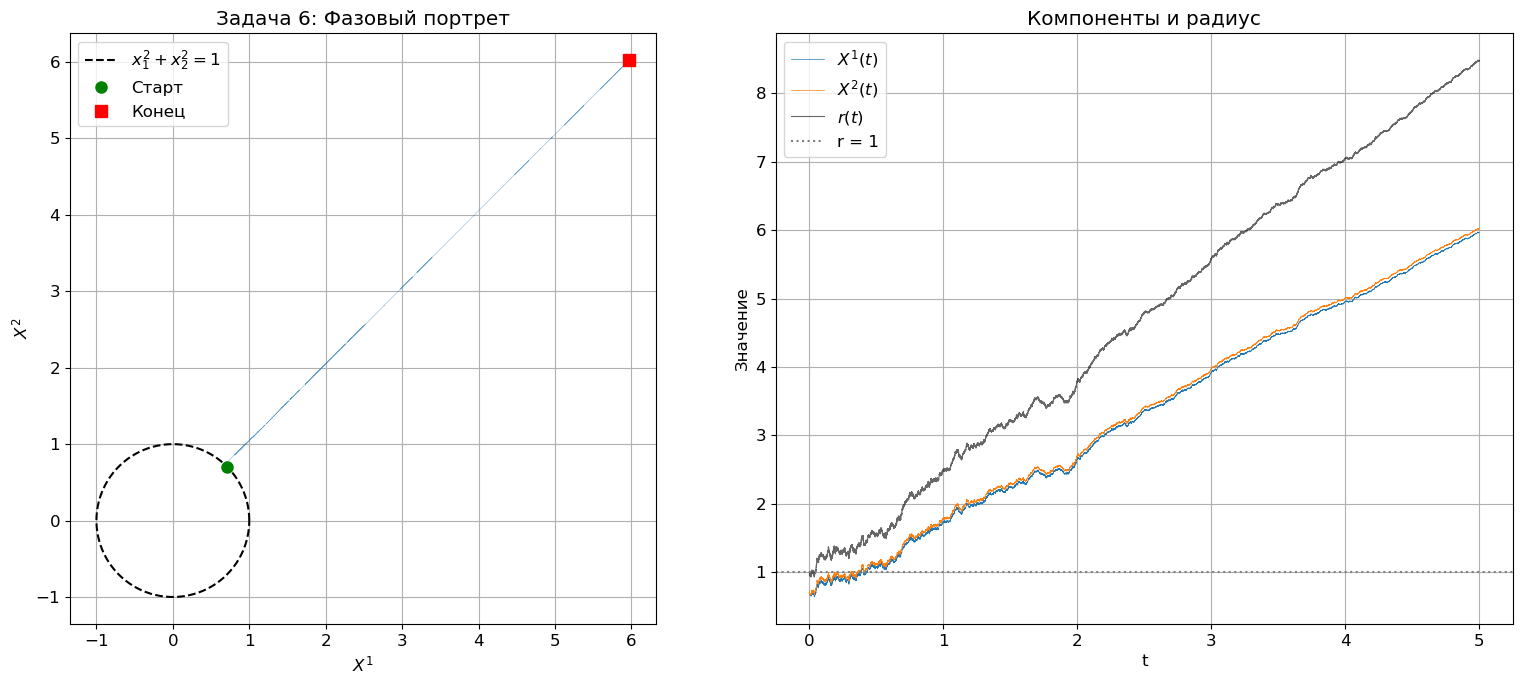

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Фазовый портрет
ax = axes[0]
theta_circle = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta_circle), np.sin(theta_circle), "k--", lw=1.5, label="$x_1^2+x_2^2=1$")
ax.plot(X[:, 0], X[:, 1], lw=0.3, alpha=0.7)
ax.plot(*X[0], "go", ms=8, label="Старт")
ax.plot(*X[-1], "rs", ms=8, label="Конец")
ax.set(xlabel="$X^1$", ylabel="$X^2$", title="Задача 6: Фазовый портрет")
ax.set_aspect("equal")
ax.legend()

# Покомпонентные графики
ax2 = axes[1]
ax2.plot(t_6, X[:, 0], lw=0.5, label="$X^1(t)$")
ax2.plot(t_6, X[:, 1], lw=0.5, label="$X^2(t)$")
r_t = np.sqrt(X[:, 0] ** 2 + X[:, 1] ** 2)
ax2.plot(t_6, r_t, "k-", lw=0.8, alpha=0.6, label="$r(t)$")
ax2.axhline(1.0, color="gray", ls=":", label="r = 1")
ax2.set(xlabel="t", ylabel="Значение", title="Компоненты и радиус")
ax2.legend()

plt.tight_layout()
plt.show()

**Вывод:**
- При $r > 1$ дрейф $(1, 1)^\top$ смещает процесс вправо-вверх; при $r \le 1$ дрейф $(-x_1, x_2)^\top$ стягивает по первой компоненте.
- Диффузия вырождена (второй столбец нулевой): шум действует только вдоль вектора $(x_1, x_2)^\top$, масштабированного $1/(1+r^2)$.
- Траектория демонстрирует сложное поведение вблизи единичной окружности, совершая переходы между областями $r < 1$ и $r > 1$.